# Mechanical P-Bit

In [1]:
import jax
import jax.numpy as jnp
from jax import random, vmap, grad, hessian
from scipy.stats import multivariate_normal
from scipy.linalg import inv

import diffrax
import matplotlib.pyplot as plt

from diffrax import ControlTerm, MultiTerm, ODETerm, PIDController

from oscillator_energies import energy_network

jax.config.update("jax_enable_x64", True)

CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


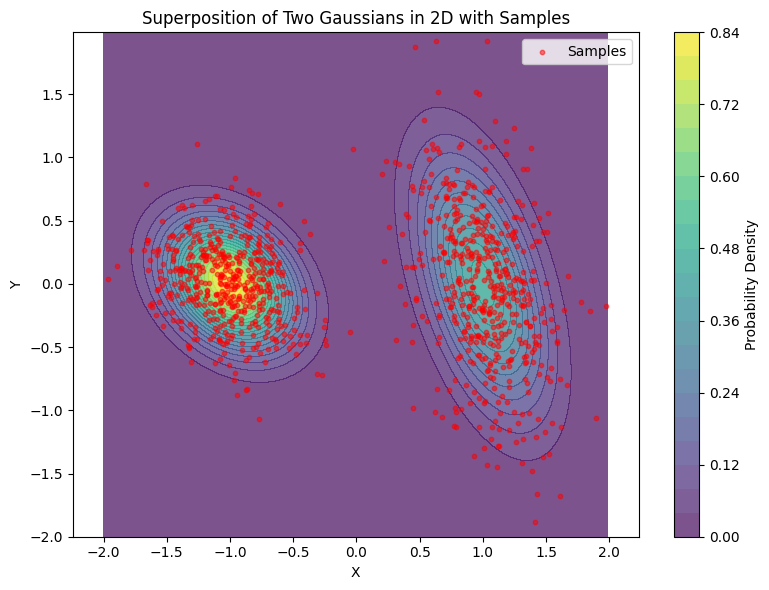

In [2]:
def sample_from_superposition(mu1, sigma1, mu2, sigma2, p1, n_samples, key):
    """
    Samples from a superposition of two Gaussian distributions in 2D using JAX.
    """
    key1, key2, key3 = random.split(key, 3)
    
    # Sample from both Gaussians
    samples1 = random.multivariate_normal(key1, mu1, sigma1, shape=(n_samples,))
    samples2 = random.multivariate_normal(key2, mu2, sigma2, shape=(n_samples,))
    
    # Generate random numbers to decide which sample to keep
    choices = random.uniform(key3, shape=(n_samples,)) < p1
    
    # Select samples based on the choices
    samples = jnp.where(choices[:, None], samples1, samples2)
    
    return samples

def gaussian_pdf(x, y, mu, sigma):
    """Compute the PDF of a 2D Gaussian distribution."""
    pos = jnp.dstack((x, y))
    return multivariate_normal.pdf(pos, mean=mu, cov=sigma)

# Parameters for the first Gaussian
mu1 = jnp.array([1, 0])
sigma1 = jnp.array([[0.1, -0.1], [-0.1, 0.4]])

# Parameters for the second Gaussian
mu2 = jnp.array([-1, 0])
sigma2 = jnp.array([[0.1, -0.03], [-.03, 0.1]])

# Probability of sampling from the first Gaussian
p1 = 0.5

# Number of samples to generate
n_samples = 1000

# JAX random key
key = random.PRNGKey(0)

# Generate samples
samples = sample_from_superposition(mu1, sigma1, mu2, sigma2, p1, n_samples, key)

# Create a grid for the contour plot
x_lim = 2
y_lim = 2
x, y = jnp.mgrid[-x_lim:x_lim:.01, -y_lim:y_lim:.01]

# Compute the PDF for both Gaussians
z1 = gaussian_pdf(x, y, mu1, sigma1)
z2 = gaussian_pdf(x, y, mu2, sigma2)

# Combine the PDFs according to the mixture weights
z = p1 * z1 + (1 - p1) * z2

# Create the plot
plt.figure(figsize=(8, 6))

# Plot the contour of the combined distribution
plt.contourf(x, y, z, levels=20, cmap='viridis', alpha=0.7)
plt.colorbar(label='Probability Density')

# Plot the samples
plt.scatter(samples[:, 0], samples[:, 1], color='red', alpha=0.5, s=10, label='Samples')

plt.title('Superposition of Two Gaussians in 2D with Samples')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

## 1. Define Parameters

In [3]:
m = jnp.array([1., 1.])
eig_freq = jnp.array([1., 1.])
k_lin= eig_freq**2*m
k_duff = jnp.array([1., 1.])
c_lin = jnp.zeros(1)
c_optomech = jnp.array([1.])
connectivity = jnp.array([[0, 1]])
damping = jnp.array([.1, .1])


k_b = 1.0             # Boltzmann's constant (arbitrary units for simulation)
T = .2             # Temperature (K)
 

# Simulation Parameters
period = 1/eig_freq[0]
t0 = 0.0  
num_periods = 2000# Start time
t1 = num_periods*period
dt0 = period/1000
num_pts_per_period = 100
ts_dim = jnp.linspace(t0, t1, num_periods*num_pts_per_period)

# Initial Conditions
y0 = jnp.zeros(2)



In [4]:
energy_network_marg = energy_network
energy_network_x = lambda x: energy_network(x, k_lin, k_duff, c_lin, c_optomech, connectivity,1.,1.)
sign_hess = -1

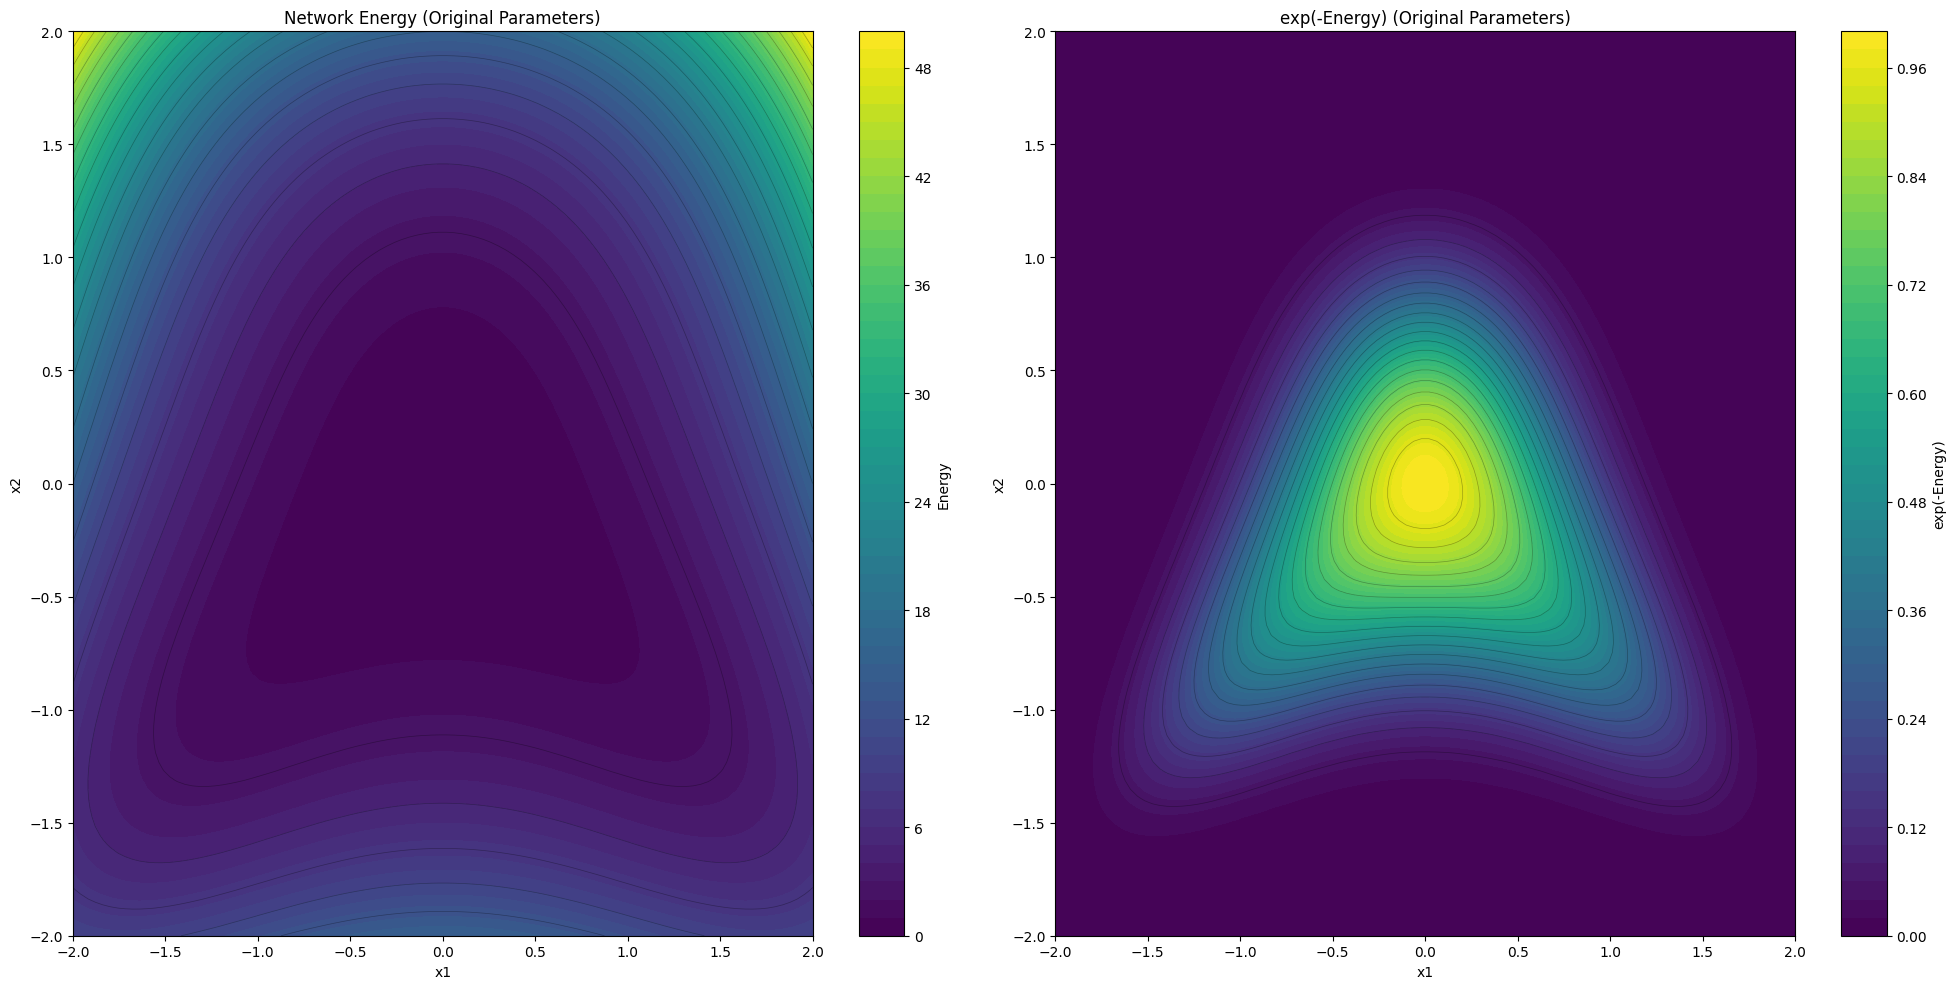

Original parameters: k_lin=[1. 1.], k_duff=[1. 1.], c_lin=[0.], c_optomech=[1.]
Integration limits: (-2, 2)


In [5]:
integration_limits = (-2, 2)
num_integration_points = 10
# Define the grid for plotting using integration limits
x1_values = jnp.linspace(integration_limits[0], integration_limits[1], 100)
x2_values = jnp.linspace(integration_limits[0], integration_limits[1], 100)
X1, X2 = jnp.meshgrid(x1_values, x2_values)

# Calculate energy values for original parameters
energy_values_original = vmap(lambda x1, x2: -1*sign_hess*energy_network_marg(jnp.array([x1, x2]), k_lin, k_duff, c_lin, c_optomech, connectivity,k_b,T))(X1.ravel(), X2.ravel())
energy_values_original = energy_values_original.reshape(X1.shape)

# Calculate exp(-energy) values
exp_neg_energy = jnp.exp(-energy_values_original)

# Create the plot with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Plot original energy
contour1 = ax1.contourf(X1, X2, energy_values_original, levels=50, cmap='viridis')
ax1.set_title("Network Energy (Original Parameters)")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
cbar1 = fig.colorbar(contour1, ax=ax1, label='Energy')

# Add contour lines for better visibility of energy levels
ax1.contour(X1, X2, energy_values_original, levels=20, colors='k', alpha=0.3, linewidths=0.5)

# Plot exp(-energy)
contour2 = ax2.contourf(X1, X2, exp_neg_energy, levels=50, cmap='viridis')
ax2.set_title("exp(-Energy) (Original Parameters)")
ax2.set_xlabel("x1")
ax2.set_ylabel("x2")
cbar2 = fig.colorbar(contour2, ax=ax2, label='exp(-Energy)')

# Add contour lines for better visibility of exp(-energy) levels
ax2.contour(X1, X2, exp_neg_energy, levels=20, colors='k', alpha=0.3, linewidths=0.5)

plt.tight_layout()
plt.show()

# Print original parameter values for reference
print(f"Original parameters: k_lin={k_lin}, k_duff={k_duff}, c_lin={c_lin}, c_optomech={c_optomech}")
print(f"Integration limits: {integration_limits}")

In [6]:
# Define lists of optimized and non-optimized parameters
optimized_params = [k_lin, k_duff,c_optomech,c_lin]
non_optimized_params = []

def loss_fn(*opt_params):
    # Combine optimized and non-optimized parameters
    all_params = list(opt_params) + non_optimized_params
    k_lin, k_duff, c_lin, c_optomech = all_params

    def current_network_energy(x):
        return energy_network_marg(x, k_lin, k_duff, c_lin, c_optomech, connectivity,k_b,T)
    
    current_score = grad(current_network_energy)
    current_score2 = hessian(current_network_energy)

    
    current_score_loss_per_sample = lambda x: (sign_hess*jnp.trace(current_score2(x)) + 1/2 * jnp.sum(current_score(x)**2))/n_samples   
    return jnp.sum(vmap(current_score_loss_per_sample)(samples))

# Compute gradients of the loss with respect to optimized parameters
# @jit
def grad_loss(*opt_params):
    return grad(loss_fn, argnums=range(len(opt_params)))(*opt_params)

# Compute Hessian of the loss function for optimized parameters
# @jit
def hessian_loss(*opt_params):
    return hessian(loss_fn, argnums=range(len(opt_params)))(*opt_params)


In [7]:
grad_loss(k_lin, k_duff, c_lin, c_optomech)

(Array([14.09433699,  0.17064252], dtype=float64),
 Array([18.48669793,  2.00658297], dtype=float64),
 Array([29.67320101], dtype=float64),
 Array([13.7992458], dtype=float64))

## 2. Define drift and diffusion functions for SDE

In [18]:
# 2.1. Direct Integration SDE for x(t)
def drift_x_fn(t, state, args):
    """
    Drift function for the direct integration of x(t).
    """
    x1, x2 = state
    return -inv(jnp.diag(damping))@grad(energy_network_x)(jnp.array([x1, x2]))

def diffusion_x_fn(t, state, args):
    """
    Diffusion 
    """
    return jnp.sqrt(2*k_b*T*inv(jnp.diag(damping)))

## 3. Solve SDE

In [19]:
w_shape = (2,)  # state is (x1, p1)
brownian_motion = diffrax.VirtualBrownianTree(
    t0, t1, 1.e-11, w_shape, random.PRNGKey(0), diffrax.SpaceTimeLevyArea
)
terms_x = MultiTerm(ODETerm(drift_x_fn), ControlTerm(diffusion_x_fn, brownian_motion))

saveat = diffrax.SaveAt(ts=ts_dim)

# sample 1000 points
solution_x = diffrax.diffeqsolve(
    terms_x,
    solver=diffrax.SRA1(),
    t0=t0,
    t1=t1,
    dt0=dt0,
    y0=y0,
    args=(),
    saveat=saveat,
    progress_meter=diffrax.TqdmProgressMeter(),
    max_steps=100000000000,
    stepsize_controller=PIDController(rtol=1e-10, atol=1e-10),
)

TracerArrayConversionError: The numpy.ndarray conversion method __array__() was called on traced array with shape float64[2,2]
The error occurred while tracing the function _fn at /home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/equinox/_eval_shape.py:31 for jit. This value became a tracer due to JAX operations on these lines:

  operation a:f64[2,2] = pjit[
  name=_diag
  jaxpr={ lambda ; b:f64[2]. let
      c:f64[2] = pad[padding_config=((0, 0, 0),)] b 0.0
      d:i64[2,2] = iota[dimension=0 dtype=int64 shape=(2, 2)] 
      e:i64[2,2] = iota[dimension=1 dtype=int64 shape=(2, 2)] 
      f:i64[2,2] = add d 0
      g:bool[2,2] = eq f e
      h:f64[2] = broadcast_in_dim[broadcast_dimensions=() shape=(2,)] 0.0
      i:f64[2,2] = pjit[
        name=_where
        jaxpr={ lambda ; j:bool[2,2] k:f64[2] l:f64[2]. let
            m:f64[2,2] = broadcast_in_dim[
              broadcast_dimensions=(1,)
              shape=(2, 2)
            ] k
            n:f64[2,2] = broadcast_